<a href="https://colab.research.google.com/github/fernandahernandezhernandez276-netizen/AF6/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Cargar el conjunto de datos MNIST
(train_data, train_labels), (test_data, test_label) = tf.keras.datasets.mnist.load_data()

# Preprocesamiento: Normalizar los datos y hacer el reshape para la CNN (28x28x1 canales)
train_data = train_data.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_data = test_data.reshape((10000, 28, 28, 1)).astype('float32') / 255

print(f"Datos de entrenamiento: {train_data.shape}")
print(f"Datos de prueba: {test_data.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Datos de entrenamiento: (60000, 28, 28, 1)
Datos de prueba: (10000, 28, 28, 1)


In [2]:
# Proponer la estructura del modelo (CNN)
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # Capa de salida requerida con softmax
])

# Establecer función de pérdida, optimizador y métrica (accuracy)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Entrenar el modelo con la función fit
# Guardamos el historial para que puedas analizar el rendimiento
history = model.fit(train_data, train_labels, epochs=5, batch_size=64, validation_split=0.1)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9707 - loss: 0.0975 - val_accuracy: 0.9867 - val_loss: 0.0474
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 86s 57ms/step - accuracy: 0.9839 - loss: 0.0522 - val_accuracy: 0.9870 - val_loss: 0.0443
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 56ms/step - accuracy: 0.9880 - loss: 0.0377 - val_accuracy: 0.9878 - val_loss: 0.0385
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9904 - loss: 0.0292 - val_accuracy: 0.9888 - val_loss: 0.0407
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 57ms/step - accuracy: 0.9929 - loss: 0.0223 - val_accuracy: 0.9903 - val_loss: 0.0382


In [5]:
# Evaluar el modelo con los datos de prueba
test_loss, test_acc = model.evaluate(test_data, test_label, verbose=2)
print(f"\nExactitud en el conjunto de prueba: {test_acc:.4f}")

313/313 - 3s - 9ms/step - accuracy: 0.9899 - loss: 0.0327

Exactitud en el conjunto de prueba: 0.9899


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


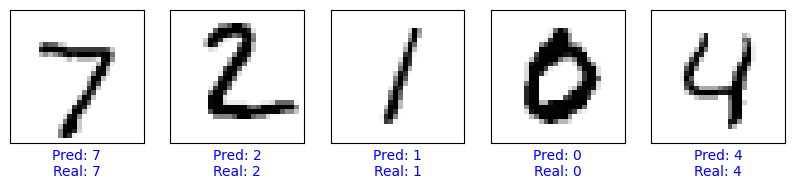

In [6]:
# Realizar predicciones
predictions = model.predict(test_data[:5])

# Mostrar los resultados
plt.figure(figsize=(10, 2))
for i in range(5):
    # Obtener el índice con la mayor probabilidad
    predicted_label = np.argmax(predictions[i])
    true_label = test_label[i]

    # Graficar la imagen para validación visual
    plt.subplot(1, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_data[i].reshape(28, 28), cmap=plt.cm.binary)
    plt.xlabel(f"Pred: {predicted_label}\nReal: {true_label}", color='blue' if predicted_label == true_label else 'red')
plt.show()